# Mine-Subsidence Early-Warning — Full Run & Score

Runs the **entire** `src/minesub/` pipeline top to bottom from the live data sources, then reports how well
both models forecast the hazard, **at the end** (§8).

```
CA DWR displacement  ┐
Open-Meteo weather    ├─► timeseries ─► features (+ Kalman) ─► labels ─► temporal split ─► train GBDT + LSTM ─► SCORE
(synthetic fallback)  ┘
```

**Task = regression.** Instead of a 3-class `safe/watch/critical` cut (whose boundary is an arbitrary quantile),
the models predict a continuous quantity: the **forward settlement rate in excess of the node's own trailing
rate** (`y_reg`, mm/day). It's scored with MAE / R² / Spearman **and** a recall-tuned operating point — the
decision threshold that catches a target share of real hazard windows. Flip `labels.task` back to
`classification` in `config/config.yaml` to get the old 3-class behaviour (labels are still computed).

Re-run top-to-bottom (`Kernel ▸ Restart & Run All`) for a clean rebuild.

## 1 — Setup

In [1]:
import os, sys, json, time, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
os.environ.setdefault("OMP_NUM_THREADS", "4")

ROOT = Path().resolve()
while not (ROOT / "src" / "minesub").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
os.chdir(ROOT); sys.path.insert(0, str(ROOT / "src"))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
try: get_ipython().run_line_magic("matplotlib", "inline")
except Exception: pass
pd.set_option("display.max_columns", 60); pd.set_option("display.width", 170)

from minesub.config import load_config
cfg = load_config(); cfg.ensure_dirs()
PROC = cfg.paths["processed"]
TASK = cfg["labels"].get("task", "classification")
KF = cfg["features"].get("kalman", {})
print("repo root :", ROOT)
print("python    :", sys.version.split()[0])
print("config    :", cfg.path)
print("date range:", cfg["data"]["min_date"], "->", cfg["data"]["max_date"])
print("window    :", cfg["features"]["backward_window_days"], "d back  /",
      cfg["features"]["forward_horizon_days"], "d forward")
print("TASK      :", TASK, " | kalman features:", KF.get("enabled", False))
assert TASK == "regression", "this notebook is written for labels.task = regression"

repo root : /Users/anand/Documents/dev/SIH
python    : 3.11.16
config    : /Users/anand/Documents/dev/SIH/config/config.yaml
date range: 1992-01-01 -> 2026-08-23
window    : 30 d back  / 21 d forward
TASK      : regression  | kalman features: True


## 2 — Collect from source

`load_ground_displacement` → CA DWR CKAN (`data.ca.gov`); `load_weather` → Open-Meteo archive API, one call per
station (responses cached under `data/raw/weather/`). If a source is unreachable, a labelled **synthetic
surrogate** with the same schema is returned and every row is tagged `data_source="synthetic_fallback"` — §8
checks for that.

In [2]:
from minesub.data.sources import load_ground_displacement, load_weather

t0 = time.time()
disp = load_ground_displacement(cfg)
stations = disp.groupby("station_id")[["lat", "lon"]].first().reset_index()
wx = load_weather(cfg, stations)
print(f"\ncollected in {time.time()-t0:.1f}s")
print("displacement :", disp.shape, "|", disp["station_id"].nunique(), "stations |",
      "source:", sorted(disp["data_source"].unique()))
print("weather      :", wx.shape, "| source:", sorted(wx["data_source"].unique()))
display(disp.head(3)); display(wx.head(3))

23:03:30  INFO     minesub.data.sources  CA DWR timeseries resource 'Ground Surface Displacement - Daily Mean': (98602, 4)


23:03:32  INFO     minesub.data.sources  joined station coords (11 stations)


23:03:32  INFO     minesub.data.sources  QC filter kept 87880 / 93577 rows


23:03:32  INFO     minesub.data.sources  displacement unit scale -> mm: x304.8 (99p span=1.29 raw)


23:03:32  INFO     minesub.data.sources  CA DWR feed: 87880 rows, 11 stations


23:03:32  INFO     minesub.data.sources  weather: 139194 rows; stations by source: {'open-meteo': 11}



collected in 12.2s
displacement : (87880, 6) | 11 stations | source: ['ca_dwr']
weather      : (139194, 6) | source: ['open-meteo']


,station_id,date,lat,lon,settlement_mm,data_source
0,09N03E08C004M,1992-01-25,38.64643,-121.667384,-0.0000,ca_dwr
1,09N03E08C004M,1992-01-26,38.64643,-121.667384,-0.0000,ca_dwr
2,09N03E08C004M,1992-01-27,38.64643,-121.667384,-0.3048,ca_dwr


,station_id,date,temp_c,humidity_pct,rain_mm,data_source
0,09N03E08C004M,1992-01-01,7.1,82,0.0,open-meteo
1,09N03E08C004M,1992-01-02,6.8,78,0.0,open-meteo
2,09N03E08C004M,1992-01-03,6.9,77,0.0,open-meteo


## 3 — Build the per-station daily timeseries  (resample + derived tilt + weather join)

In [3]:
from minesub.data.build import build_timeseries
ts = build_timeseries(cfg, save=True)
print("\ntimeseries :", ts.shape, "|", ts["station_id"].nunique(), "stations |",
      ts["date"].min().date(), "->", ts["date"].max().date())
print("disp source(s):", sorted(ts["data_source_disp"].unique()),
      "| wx source(s):", sorted(ts["data_source_wx"].unique()))
display(ts.head(3))

23:03:35  INFO     minesub.data.sources  CA DWR timeseries resource 'Ground Surface Displacement - Daily Mean': (98602, 4)


23:03:36  INFO     minesub.data.sources  joined station coords (11 stations)


23:03:36  INFO     minesub.data.sources  QC filter kept 87880 / 93577 rows


23:03:36  INFO     minesub.data.sources  displacement unit scale -> mm: x304.8 (99p span=1.29 raw)


23:03:36  INFO     minesub.data.sources  CA DWR feed: 87880 rows, 11 stations


...

23:03:36  INFO     minesub.data.build  timeseries: 96801 rows, 11 stations, 1992-10-21 -> 2026-08-18


23:03:36  INFO     minesub.data.build  displacement source(s): ['ca_dwr'] | weather source(s): ['open-meteo']


23:03:36  INFO     minesub.data.build  wrote /Users/anand/Documents/dev/SIH/data/processed/timeseries.parquet



timeseries : (96801, 11) | 11 stations | 1992-10-21 -> 2026-08-18
disp source(s): ['ca_dwr'] | wx source(s): ['open-meteo']


,station_id,date,distance_mm,lat,lon,data_source_disp,tilt_deg,temp_c,humidity_pct,rain_mm,data_source_wx
0,09N03E08C004M,1992-10-21,24.0792,38.64643,-121.667384,ca_dwr,-0.002093,18.8,77,13.0,open-meteo
1,09N03E08C004M,1992-10-22,23.4696,38.64643,-121.667384,ca_dwr,0.001020,17.9,65,0.0,open-meteo
2,09N03E08C004M,1992-10-23,23.1648,38.64643,-121.667384,ca_dwr,-0.000221,19.0,57,0.0,open-meteo


## 4 — Feature engineering

Backward 30-day window → feature vector; forward 21-day horizon → target signals. With `features.kalman.enabled`,
a constant-acceleration **Kalman smoother** (`src/minesub/kalman.py`) runs on `distance_mm` / `tilt_deg` and adds
`dist_kf_rate`, `dist_kf_accel`, `dist_kf_level`, … — cleaner level/rate/accel than the polyfit slopes, and it
runs online so it is deployable on a field node.

In [4]:
from minesub.features import build_feature_table, feature_columns
samples = build_feature_table(cfg, ts=ts, save=True)
feat_cols = feature_columns(samples)
kf_cols = [c for c in feat_cols if "_kf_" in c]
print("\nsamples :", samples.shape, "|", len(feat_cols), "model features",
      f"({len(kf_cols)} Kalman-derived)")
print("features   :", feat_cols)
print("kalman     :", kf_cols)

23:04:14  INFO     minesub.features  feature table: 13754 samples, 11 stations, 1992-11-19 -> 2026-07-26


23:04:14  INFO     minesub.features  wrote /Users/anand/Documents/dev/SIH/data/processed/samples.parquet



samples : (13754, 40) | 32 model features (7 Kalman-derived)
features   : ['days_since_start', 'distance_last', 'distance_delta', 'distance_rate', 'distance_accel', 'distance_std', 'distance_range', 'tilt_last', 'tilt_delta', 'tilt_rate', 'tilt_accel', 'tilt_std', 'tilt_abs_last', 'humidity_mean', 'humidity_delta', 'humidity_std', 'temp_mean', 'temp_range', 'temp_std', 'rain_sum', 'rain_max', 'rain_recent7', 'rain_days', 'doy_sin', 'doy_cos', 'dist_kf_level', 'dist_kf_rate', 'dist_kf_accel', 'dist_kf_rate_std', 'dist_kf_rate_delta', 'tilt_kf_rate', 'tilt_kf_accel']
kalman     : ['dist_kf_level', 'dist_kf_rate', 'dist_kf_accel', 'dist_kf_rate_std', 'dist_kf_rate_delta', 'tilt_kf_rate', 'tilt_kf_accel']


## 5 — Labels

`add_risk_labels` always computes the 3-class `risk_class` (for reference) **and** the regression target
`y_reg` = `fwd_settlement_rate − distance_rate` (forward excess settlement rate, mm/day, 7-day-smoothed forward
window). `y_reg` is what the models train on here. It's zero-centred with a right tail: most windows show no
acceleration beyond the node's trailing behaviour; a few show a lot.

23:04:14  INFO     minesub.labels  regression target y_reg (mm/day excess): median=0  p90=0.0952  p99=0.4984


23:04:14  INFO     minesub.labels  label method=quantile  distribution: {'safe': 8252, 'watch': 4126, 'critical': 1376}


23:04:14  INFO     minesub.labels  wrote /Users/anand/Documents/dev/SIH/data/processed/samples_labeled.parquet


y_reg (mm/day excess)  median 0.0000  p75 0.0281  p90 0.0952  p95 0.1671  p99 0.4984
                        mean -0.0002  std 0.1623  min -2.5929  max 1.5962

(reference) 3-class counts: {'safe': 8252, 'watch': 4126, 'critical': 1376}


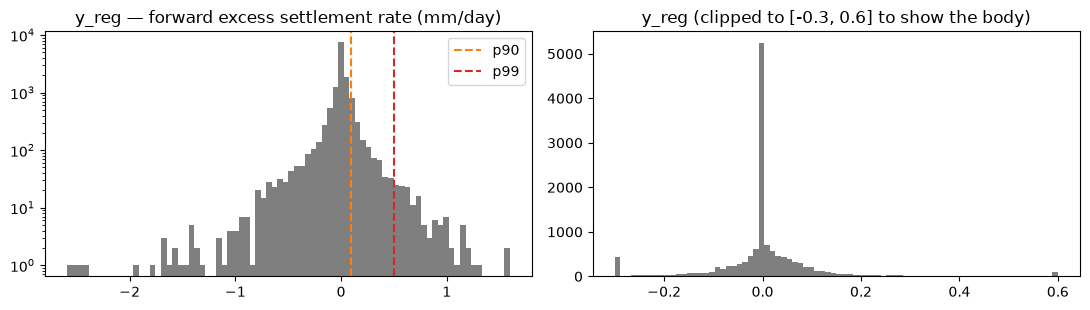

In [5]:
from minesub.labels import add_risk_labels
from minesub import RISK_CLASSES
labeled = add_risk_labels(cfg, samples, save=True)

yv = labeled["y_reg"].to_numpy()
q = np.quantile(yv, [.5, .75, .9, .95, .99])
print("y_reg (mm/day excess)  median %.4f  p75 %.4f  p90 %.4f  p95 %.4f  p99 %.4f" % tuple(q))
print("                        mean %.4f  std %.4f  min %.4f  max %.4f"
      % (yv.mean(), yv.std(), yv.min(), yv.max()))
cnts = labeled["risk_class"].value_counts().reindex(RISK_CLASSES)
print("\n(reference) 3-class counts:", {k: int(v) for k, v in cnts.items()})

fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
ax[0].hist(yv, bins=80, color="tab:gray"); ax[0].set_yscale("log")
ax[0].axvline(q[2], color="tab:orange", ls="--", label="p90"); ax[0].axvline(q[4], color="tab:red", ls="--", label="p99")
ax[0].set_title("y_reg — forward excess settlement rate (mm/day)"); ax[0].legend()
ax[1].hist(np.clip(yv, -0.3, 0.6), bins=80, color="tab:gray")
ax[1].set_title("y_reg (clipped to [-0.3, 0.6] to show the body)")
plt.tight_layout(); plt.show()

## 6 — Temporal split  (earliest 65% train · next 15% val · latest 20% test)

In [6]:
from minesub.datasplit import temporal_split
tr, va, te = temporal_split(cfg, labeled)
y = labeled["y_reg"].to_numpy()
for nm, m in [("train", tr), ("val", va), ("test", te)]:
    span = labeled.loc[m, "t"]
    yy = y[m]
    print(f"{nm:5s} n={m.sum():5d}  {span.min().date()} -> {span.max().date()}   "
          f"y_reg mean {yy.mean():+.4f}  p90 {np.quantile(yy, .9):.4f}  p99 {np.quantile(yy, .99):.4f}")

23:04:14  INFO     minesub.datasplit  split: train=8940 (<2017-12-10)  val=2063  test=2751 (>=2021-07-16)


train n= 8940  1992-11-19 -> 2017-12-10   y_reg mean -0.0004  p90 0.0987  p99 0.5055
val   n= 2063  2017-12-10 -> 2021-07-16   y_reg mean +0.0005  p90 0.0880  p99 0.6154
test  n= 2751  2021-07-16 -> 2026-07-26   y_reg mean -0.0003  p90 0.0865  p99 0.3772


## 7 — Train both models

`train(cfg, name)` re-reads the labelled samples, re-applies the temporal split, fits on `y_reg`, scores the
**held-out test split** with `evaluate_regression`, and writes `artifacts/models/` + `reports/metrics_<name>.json`
+ `reports/regression_<name>.png`.

* **GBDT** — `HistGradientBoostingRegressor` (absolute-error loss), early stopping, on the windowed feature vector.
* **LSTM** — 2-layer LSTM (hidden 64) + linear head → 1 output; Huber loss; keeps the best val-MAE epoch.

In [7]:
from minesub.train import train
metrics = {}
for name in ("gbdt", "torch"):
    print(f"\n{'='*64}\n  TRAIN  {name}\n{'='*64}")
    metrics[name] = train(cfg, name)
try: get_ipython().run_line_magic("matplotlib", "inline")   # train() flips mpl to Agg
except Exception: pass


  TRAIN  gbdt


23:04:16  INFO     minesub.datasplit  split: train=8940 (<2017-12-10)  val=2063  test=2751 (>=2021-07-16)


23:04:16  INFO     minesub.train  task=regression  model=gbdt


23:04:17  INFO     minesub.models.gbdt  trained (regression); n_iter=600 (of max 600)


23:04:19  INFO     minesub.models.gbdt  saved -> /Users/anand/Documents/dev/SIH/artifacts/models/gbdt.joblib


...

23:04:39  INFO     minesub.models.torch  done; best val_MAE=0.0550  device=mps


23:04:39  INFO     minesub.models.torch  saved -> /Users/anand/Documents/dev/SIH/artifacts/models/lstm.pt


23:04:39  INFO     minesub.evaluate  wrote /Users/anand/Documents/dev/SIH/reports/regression_torch.png


23:04:39  INFO     minesub.evaluate  [torch] MAE=0.0513  R2=0.377  spearman=0.521  PR-AUC(hazard)=0.358  | op: recall=0.60 precision=0.20 flag=30.6%


23:04:39  INFO     minesub.evaluate  wrote /Users/anand/Documents/dev/SIH/reports/metrics_torch.json


## 8 — 📊 Score

Held-out **test** split only (windows that end *after* everything the models trained on).

* **MAE / RMSE** — absolute error on the excess-rate prediction (mm/day). `y_reg` is small and zero-centred, so
  read these next to its scale (p90 ≈ 0.1 mm/day), not on their own.
* **R² / Pearson / Spearman** — how much of the variation in future behaviour the model explains / how well it
  *ranks* windows by hazard. Spearman is the one that matters for triage.
* **Operating point** — treat the top `hazard_top_frac` (10%) of the *true* excess rate as "real hazard", then
  pick the score threshold that reaches a target **recall**. Reports precision and the fraction of windows flagged
  at each. This is the number an early-warning system is actually judged on.
* **Naive baseline** — predict `y_reg = 0` for everything ("no acceleration beyond trailing rate"): R² ≤ 0 and it
  catches 0 hazards, so any positive R² / non-trivial recall is real skill.

In [8]:
def op_table(m):
    rows = {}
    for k, v in m["operating_points"].items():
        rows[k] = ({"precision": round(v["precision"], 3), "recall": round(v["recall"], 3),
                    "windows_flagged": f"{v['flagged_frac']*100:.1f}%",
                    "threshold_mm_day": round(v["threshold"], 4)} if v
                   else {"precision": None, "recall": None, "windows_flagged": None, "threshold_mm_day": None})
    return pd.DataFrame(rows).T

core = {}
for name, m in metrics.items():
    core[name] = {
        "test_samples":   m["n_samples"],
        "MAE":            round(m["mae"], 4),
        "RMSE":           round(m["rmse"], 4),
        "R2":             round(m["r2"], 3),
        "Pearson_r":      round(m["pearson_r"], 3),
        "Spearman_rho":   round(m["spearman_rho"], 3),
        "hazard_PR_AUC":  round(m["hazard_pr_auc"], 3),
        "synthetic_data": m.get("synthetic_data"),
    }
core = pd.DataFrame(core).T
mae0 = float(np.mean(np.abs(y[te])))          # naive "predict 0" baseline MAE
print(f"naive baseline (predict y_reg = 0):  MAE {mae0:.4f}   R2 0.000   hazard recall 0.000\n")
core

naive baseline (predict y_reg = 0):  MAE 0.0616   R2 0.000   hazard recall 0.000



,test_samples,MAE,RMSE,R2,Pearson_r,Spearman_rho,hazard_PR_AUC,synthetic_data
gbdt,2751,0.0484,0.1072,0.389,0.624,0.559,0.483,False
torch,2751,0.0513,0.1082,0.377,0.615,0.521,0.358,False


In [9]:
print("GBDT — operating points (min score threshold reaching each target recall)")
display(op_table(metrics["gbdt"]))
print("\nGBDT — precision @ top-k fraction of windows")
display(pd.DataFrame(metrics["gbdt"]["precision_at_topk"]).T.round(3))

GBDT — operating points (min score threshold reaching each target recall)


,precision,recall,windows_flagged,threshold_mm_day
recall>=0.5,0.523,0.5,9.6%,0.0664
recall>=0.6,0.445,0.601,13.6%,0.051
recall>=0.7,0.322,0.703,21.9%,0.0295
recall>=0.8,0.22,0.801,36.5%,0.0055



GBDT — precision @ top-k fraction of windows


,precision,recall,n
top_5pct,0.659,0.330,138.0
top_10pct,0.520,0.518,275.0
top_20pct,0.344,0.685,550.0


In [10]:
# best model by hazard ranking (Spearman), then its chosen deploy operating point
best = max(metrics, key=lambda k: metrics[k]["spearman_rho"])
m = metrics[best]; c = m["chosen_operating_point"]
print("="*66)
print(f"  HEADLINE  —  best model: {best.upper()}   (task: regression)")
print("="*66)
print(f"  explains R2 = {m['r2']:.2f} of forward-behaviour variance")
print(f"  ranks hazard: Spearman rho = {m['spearman_rho']:.2f}, Pearson r = {m['pearson_r']:.2f}")
print(f"  MAE {m['mae']:.4f} mm/day   (y_reg p90 ~ {np.quantile(y, .9):.3f})")
print( "  deploy operating point:")
print(f"     catches {c['recall']*100:.0f}% of real hazard windows  at  {c['precision']*100:.0f}% precision")
print(f"     by flagging {c['flagged_frac']*100:.1f}% of all windows  (threshold {c['threshold']:.4f} mm/day excess)")
print(f"  data: {'REAL (CA DWR + Open-Meteo)' if not m.get('synthetic_data') else 'SYNTHETIC FALLBACK — not a benchmark'}")
print("="*66)
if m.get("synthetic_data"):
    print("  !! a data source was unreachable; rerun §2 with a connection for real numbers")

  HEADLINE  —  best model: GBDT   (task: regression)
  explains R2 = 0.39 of forward-behaviour variance
  ranks hazard: Spearman rho = 0.56, Pearson r = 0.62
  MAE 0.0484 mm/day   (y_reg p90 ~ 0.095)
  deploy operating point:
     catches 60% of real hazard windows  at  45% precision
     by flagging 13.6% of all windows  (threshold 0.0510 mm/day excess)
  data: REAL (CA DWR + Open-Meteo)


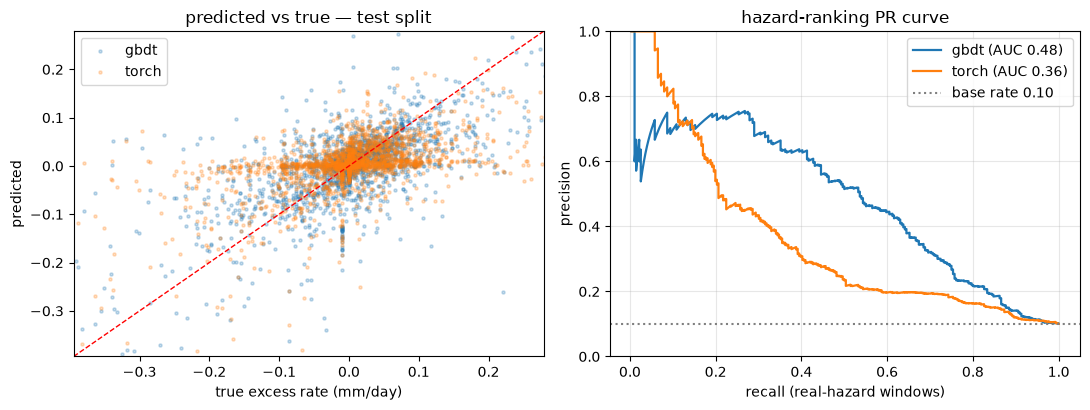

In [11]:
# rebuild predicted-vs-true + hazard PR curve inline from the saved models
from minesub.features import build_sequences
from minesub.models.gbdt_model import GbdtRiskModel
from minesub.models.torch_model import LSTMRiskModel

Xte = labeled[feat_cols].to_numpy(float)[te]
seq_te = build_sequences(cfg, labeled, ts)[te]
yte = y[te]
preds = {
    "gbdt":  GbdtRiskModel.load(cfg, cfg.paths["models"] / "gbdt.joblib").predict(Xte),
    "torch": LSTMRiskModel.load(cfg, cfg.paths["models"] / "lstm.pt").predict(seq_te),
}
thr_true = np.quantile(yte, 1 - metrics["gbdt"]["hazard_top_frac"])
pos = yte >= thr_true

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
lim = np.percentile(np.concatenate([yte, preds["gbdt"], preds["torch"]]), [1, 99])
for name, col in [("gbdt", "tab:blue"), ("torch", "tab:orange")]:
    ax[0].scatter(yte, preds[name], s=5, alpha=.25, color=col, label=name)
    order = np.argsort(-preds[name]); ps = pos[order]
    tp = np.cumsum(ps); fp = np.cumsum(~ps)
    rec = tp / max(pos.sum(), 1); prec = tp / np.maximum(tp + fp, 1)
    ax[1].plot(rec, prec, color=col, lw=1.6, label=f"{name} (AUC {metrics[name]['hazard_pr_auc']:.2f})")
ax[0].plot(lim, lim, "r--", lw=1); ax[0].set_xlim(*lim); ax[0].set_ylim(*lim)
ax[0].set_xlabel("true excess rate (mm/day)"); ax[0].set_ylabel("predicted"); ax[0].legend()
ax[0].set_title("predicted vs true — test split")
ax[1].axhline(pos.mean(), color="gray", ls=":", label=f"base rate {pos.mean():.2f}")
ax[1].set_xlabel("recall (real-hazard windows)"); ax[1].set_ylabel("precision")
ax[1].set_ylim(0, 1); ax[1].legend(); ax[1].set_title("hazard-ranking PR curve"); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

In [12]:
core.to_csv(cfg.paths["reports"] / "run_and_score_summary.csv")
print("saved ->", cfg.paths["reports"] / "run_and_score_summary.csv")
print("per-model metrics JSON : reports/metrics_gbdt.json , reports/metrics_torch.json")
print("regression plots       : reports/regression_gbdt.png , reports/regression_torch.png")
print("saved models           : artifacts/models/gbdt.joblib , artifacts/models/lstm.pt")

saved -> /Users/anand/Documents/dev/SIH/reports/run_and_score_summary.csv
per-model metrics JSON : reports/metrics_gbdt.json , reports/metrics_torch.json
regression plots       : reports/regression_gbdt.png , reports/regression_torch.png
saved models           : artifacts/models/gbdt.joblib , artifacts/models/lstm.pt
